# Comparison of Monte Carlo simulations against Black-Scholes model
Black-Scholes model assumes that asset prices follow geometric Brownian motion.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [6]:
# Set to None for pseudo-random results, 42 for reproducing the results in README.md
rng_seed = 42

## Generate synthetic option prices from geometric Brownian motion

The time-evolution of the price $S(t)$ of an asset that is governed by geometric Brownian motion can be described by the stochastic differential equation,
$$dS(t)=\mu S_t dt + \sigma S_t dW(t) \tag{1}.$$
with $\mu$ and $\sigma$ as the drift and volatility of the asset respectively. $W(t)$ is the price according to the standard Wiener process (also known as standard Brownian motion) at time $t$. Using Itô's lemma, we obtain the solution
$$S(t)=S(0) \exp[(\mu-\frac{1}{2}\sigma^2)t+\sigma W(t)] \tag{2}.$$
The recursion relation of a standard Wiener trajectory across $n$ steps for all $i \in \{0, 1, ..., n\}$ is given by Eq. 3.2 from Glasserman (2003) [1],
$$ W(t_{i+1})=W(t_i)+\sqrt{t_{i+1}-t_i} Z_{i+1} \tag{3}, $$
where $Z_{i}$ is a sample randomly drawn from a standard normal distribution $\mathcal{N}(0,1)$. Thus the recursive relation of the asset price is
$$ \frac{S(t_{i+1})}{S(t_i)}=\exp[(\mu-\frac{1}{2}\sigma^2)(t_{i-1}-t_i)+\sigma\sqrt{t_{i+1}-t_i}Z_{i+1}]. \tag{4} $$

In [7]:
def generate_gbm(s0: float, mu: float, sigma: float, T: float, n_steps, n_paths, seed=None):
    '''
    Generates a matrix of geometric brownian motion trajectories, with n_steps 
    rows and n_paths columns. 

    Parameters
    ----------
    s0: Initial stock price
    mu: Drift coefficient of asset
    sigma: Volatility coefficient of asset
    T: Total duration of simulation in years
    n_steps: Number of time steps in the simulation
    n_paths: Number of simulated paths to be generated
    seed: Random number generator seed, can be set for reproducibility
    '''

    dt = T / n_steps
    rng = np.random.default_rng(seed)

    # Draw samples from standard normal distribution
    Z = rng.normal(0, 1, size=(n_steps, n_paths))

    # Multiplication factor per step
    step_factors = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

    # Insert a row of 1s at the top to represent the t=0 state
    step_factors = np.vstack([np.ones((1, n_paths)), step_factors])

    # Cumulative product of asset prices
    paths = s0 * np.cumprod(step_factors, axis=0)

    return paths

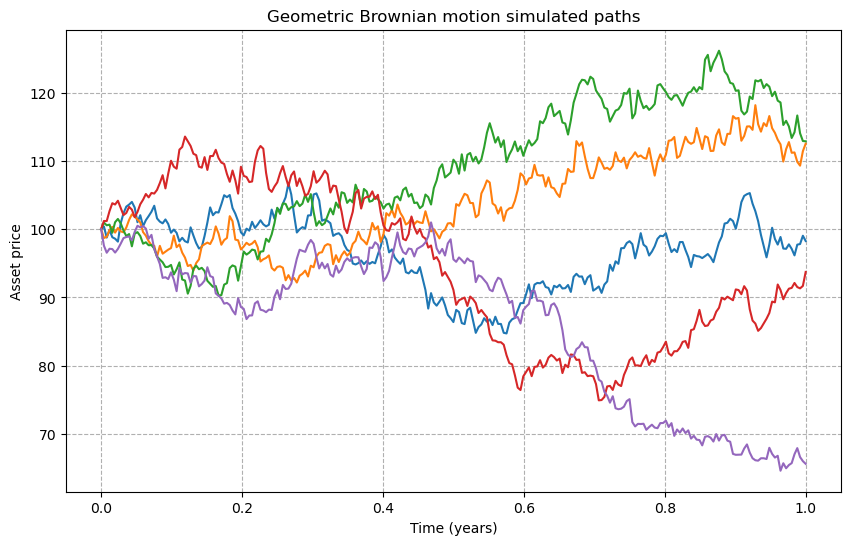

In [8]:
# Plot GBM trajectories
s0 = 100.0
mu = 0.05
sigma = 0.2
time_horizon = 1.0 # 1 year
num_steps = 252 # Assume 252 trading days in a year
num_paths = 5
t_grid = np.linspace(0.0, time_horizon, num_steps+1)
gbm_sims = generate_gbm(s0, mu, sigma, time_horizon, num_steps, num_paths, rng_seed)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, gbm_sims)
plt.title(f"Geometric Brownian motion simulated paths")
plt.xlabel("Time (years)")
plt.ylabel("Asset price")
plt.grid(ls="--")
plt.show()

## Determine premium of European options
The premium of an option is the price at which the options contract is sold. 

### European call options
Call options give their owners the right, but not the obligation, to buy an underlying asset at a strike price $K$. European-style options can only be executed at maturity $T$. These definitions tell us that the fair price of an European call option at maturity is the expected payoff
$$C(t=T) = \mathbb{E}[\text{payoff}] = \mathbb{E}[\max(0, S_T-K)] \tag{5}.$$
To calculate $C$, we define a variable $d$ that corresponds to zero payoff,
 $$K=S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma\sqrt{T}d\right] \tag{6},$$
and define $\phi$ and $\Phi$ as the probability and cumulative density functions of a standard normal random variable. Then the price of the call option at maturity is
$$\begin{align*}
C(t=T)&=\int_{S_T(d)}^\infty S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma\sqrt{T}z\right]\cdot\phi(S_T)dS_T-\int_{K(d)}^\infty K\phi(K)dK \\
    &=\int_d^\infty S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma\sqrt{T}z\right]\phi(z)dz-\int_d^\infty K\phi(z)dz \\
    &=S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T\right]\int_d^\infty \frac{1}{\sqrt{2\pi}}\exp\left[-\frac{1}{2}(z-\sigma\sqrt{T})^2+\frac{\sigma^2}{2} T\right]dz-K\Phi(-d) \\
    &=S_0 e^{\mu T}\int_{d-\sigma\sqrt{T}}^\infty \phi(u)du - K\Phi(-d) \\
    &=S_0 e^{\mu T}\Phi(-d+\sigma\sqrt{T})-K\Phi(-d) \\
    &=S_0 e^{\mu T}\Phi(d_1)-K\Phi(d_2) \tag{7}.
\end{align*}$$
with $d_1:=-d+\sigma\sqrt{T}$, and $d_2:=-d$.
Eq. (6) can be rearranged to 
$$d = \frac{\ln\frac{K}{S_0}-(\mu-\frac{\sigma^2}{2})T}{\sigma\sqrt{T}} \tag{8}$$
to give us
$$d_1=\frac{(\mu-\frac{\sigma^2}{2})T-\ln\frac{K}{S_0}}{\sigma\sqrt{T}}+\sigma\sqrt{T},$$
$$d_2=d_1-\sigma\sqrt{T} \tag{9}.$$
The price of the option at a point in time $t$ is the time-discounted price at maturity,
$$\begin{align*}
C(t)&=e^{-\mu (T-t)}C(t=T) \\
    &=S_0 e^{\mu t}\Phi(d_1)-Ke^{-\mu (T-t)}\Phi(d_2). \tag{10}
\end{align*}$$
### European put options
Put options give their owners the right, but not the obligation, to sell an underlying asset at a strike price $K$. By computing the put-call parity, 
$$\begin{align*}
C(t)-P(t)&=e^{-\mu (T-t)}\mathbb{E}[S_T-K] \\
    &=e^{-\mu (T-t)}\left[\int_{-\infty}^\infty S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma\sqrt{T}z\right]\cdot\phi(S_T)dS_T-K\phi(K)dK\right] \\
    &=e^{-\mu (T-t)}(S_0 e^{\mu T}-K) \\
    &=S_0 e^{\mu t}-K e^{-\mu (T-t)} \tag{11},
\end{align*}$$
we can easily obtain the fair price of an European-style put option,
$$\begin{align*}
P(t)&=S_0e^{\mu t}[\Phi(d_1)-1]+Ke^{-\mu(T-t)}[1-\Phi(d_2)] \\
    &=Ke^{-\mu(T-t)}\Phi(-d_2)-S_0e^{\mu t}\Phi(-d_1) \tag{12}.
\end{align*}$$

In [ ]:
def black_scholes_premium(s0: float, mu: float, sigma: float, T: float, K: float, otype: str):
    '''
    Computes Black-Scholes premium of an European call or put option.

    Parameters
    ----------
    s0: Initial stock price
    mu: Mean or drift coefficient of asset
    sigma: Standard devidation or volatility coefficient of asset
    T: Lifespan of option in years
    K: Strike price
    otype: Type of option, 'call' or 'put'
    '''
    if otype != 'call' and otype != 'put': 
        print(f"{otype} is an invalid otype. Must be 'call' or 'put'.")
        return None
    
    # We are only interested in the premium, ie. price of option at the time of inception.
    time = 0.0

    d1 = ((mu - sigma**2 / 2) * T - np.log(K / s0)) / sigma * np.sqrt(T) + sigma * np.sqrt(T)
    d2 = d1 - sigma * np.sqrt(T)

    if otype == 'call':
        return s0 * np.exp(mu * time) * norm.cdf(d1) - K * np.exp(-mu * (T - time)) * norm.cdf(d2)
    if otype == 'put':
        return K * np.exp(-mu * (T - time)) * norm.cdf(-d2)- s0 * np.exp(mu * time) * norm.cdf(-d1)

In [ ]:
s0 = 100.0
mu = 0.05 # Risk-free interest rate
sigma = 0.2
T = 1.0 # 1 year
K = 100.0

bs_call = black_scholes_premium(s0, mu, sigma, T, K, 'call')
bs_put = black_scholes_premium(s0, mu, sigma, T, K, 'put')

print(f"Black-Scholes European call option premium: {bs_call:.4f}")
print(f"Black-Scholes European put option premium: {bs_put:.4f}")

Black-Scholes European call option price: 10.4506
Black-Scholes European put option price: 5.5735


# References

[1] Glasserman, P. (2003). *Monte Carlo Methods in financial engineering*. Springer international publishing. 